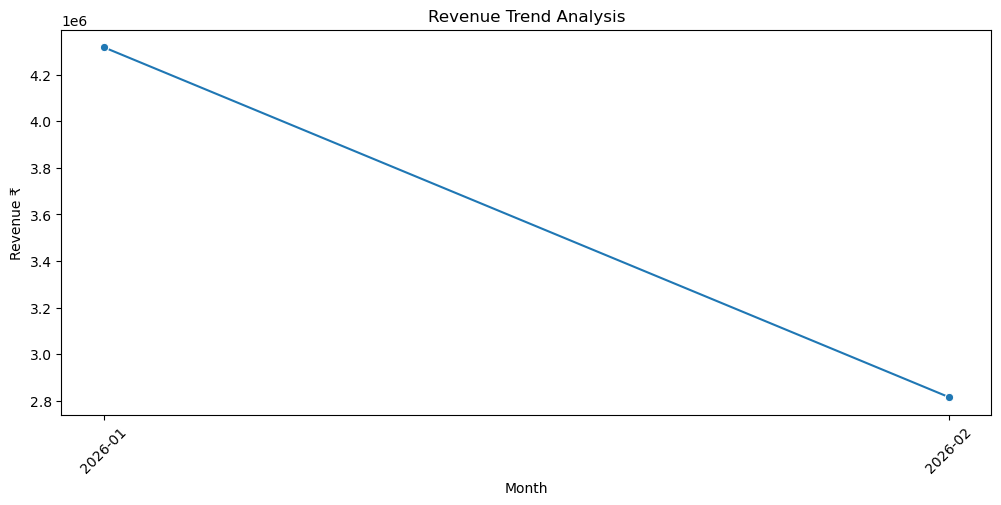

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("D:/Data Analyst DUCAT Classes/xyz/Financial_project_Data.xlsx") #Date, Revenue, Expense
df['Date'] = pd.to_datetime(df['Transaction_Date'])
df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_revenue.index.astype(str), y=monthly_revenue.values, marker='o')
plt.title('Revenue Trend Analysis')
plt.xticks(rotation=45)
plt.ylabel('Revenue ₹')
plt.show()

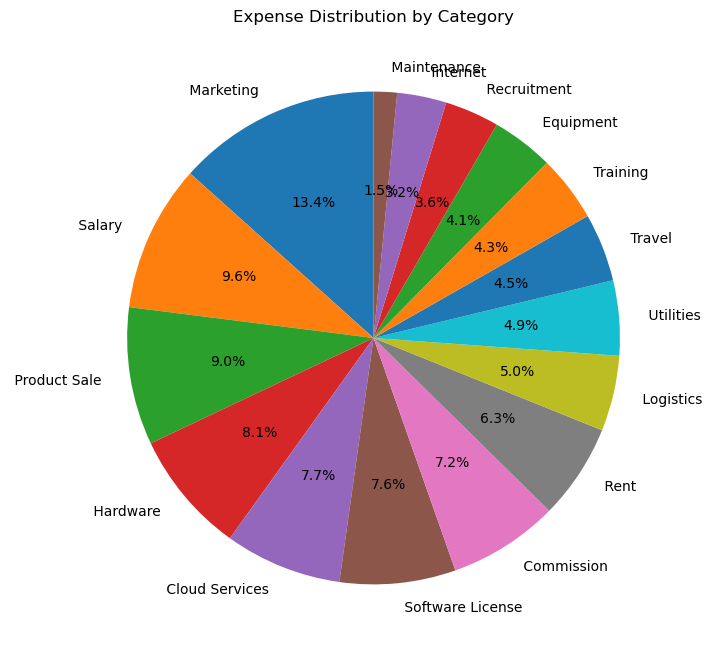

In [22]:
import matplotlib.pyplot as plt
# 1. Category wise total Expense nikal do
expense_by_category = df.groupby('Category')['Expense'].sum().sort_values(ascending=False)
# 2. Pie chart
plt.figure(figsize=(8,8))
plt.pie(expense_by_category.values, 
        labels=expense_by_category.index, 
        autopct='%1.1f%%',
        startangle=90)
plt.title('Expense Distribution by Category')
plt.show()

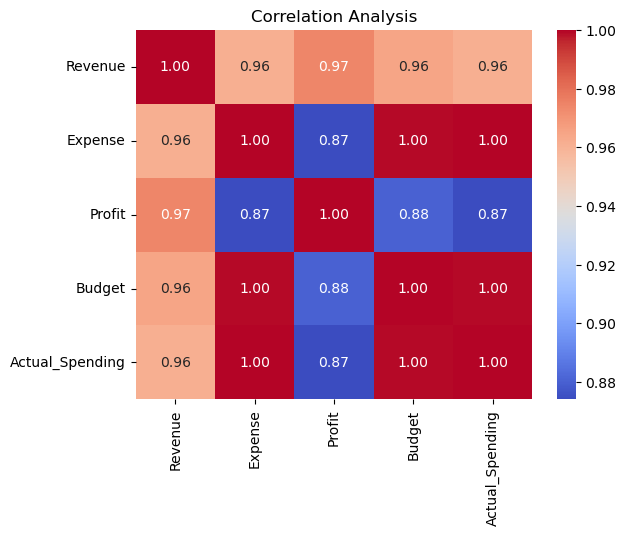

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sirf numeric wale column lo
corr = df[['Revenue', 'Expense', 'Profit', 'Budget', 'Actual_Spending']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Analysis')
plt.show()

C:\Users\Chittaranjan\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Chittaranjan\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


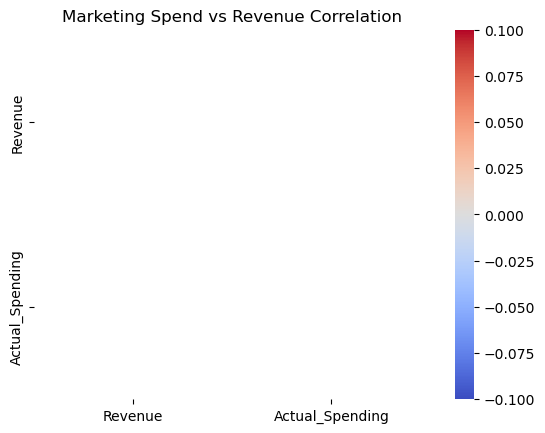

In [24]:
# Sirf Marketing wale data
marketing_df = df[df['Category'] == 'Marketing']

# Ab Marketing ka Actual_Spending vs Revenue
corr_marketing = marketing_df[['Revenue', 'Actual_Spending']].corr()

sns.heatmap(corr_marketing, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Marketing Spend vs Revenue Correlation')
plt.show()

C:\Users\Chittaranjan\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\Chittaranjan\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


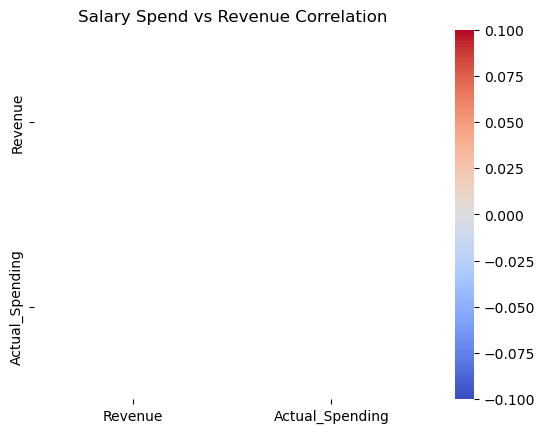

In [25]:
# Sirf Salary wale data
salary_df = df[df['Category'] == 'Salary']

corr_salary = salary_df[['Revenue', 'Actual_Spending']].corr()

sns.heatmap(corr_salary, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Salary Spend vs Revenue Correlation')
plt.show()

07:49:51 - cmdstanpy - INFO - Chain [1] start processing
07:49:51 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Chittaranjan\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


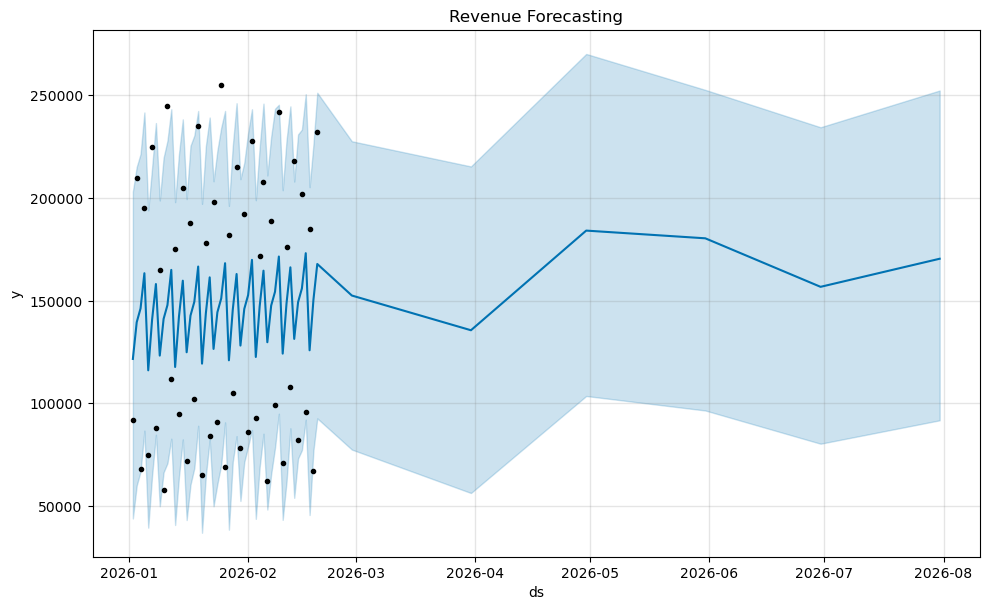

In [26]:
from prophet import Prophet

prophet_df = df[['Date', 'Revenue']].rename(columns={'Date':'ds', 'Revenue':'y'})
model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)
model.plot(forecast)
plt.title('Revenue Forecasting')
plt.show()

In [27]:
import pandas as pd
from datetime import datetime

report = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Expense', 'Net Profit', 'Profit Margin %'],
    'Value': [df['Revenue'].sum(), df['Expense'].sum(), 
              df['Revenue'].sum()-df['Expense'].sum(),
              ((df['Revenue'].sum()-df['Expense'].sum())/df['Revenue'].sum())*100]
})

filename = f"Financial_Report_{datetime.now().strftime('%B_%Y')}.xlsx"
report.to_excel(filename, index=False)
print(f"Report Saved: {filename}")

Report Saved: Financial_Report_July_2026.xlsx


In [28]:
import pandas as pd

df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Month'] = df['Transaction_Date'].dt.to_period('M')

# KPIs
total_revenue = df['Revenue'].sum()
total_expense = df['Expense'].sum()
net_profit = total_revenue - total_expense
profit_margin = (net_profit / total_revenue) * 100
budget_variance = df['Actual_Spending'].sum() - df['Budget'].sum()

print(f"Total Revenue: {total_revenue}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Budget Variance: {budget_variance}") # +ve = Overspending

Total Revenue: 7133000
Profit Margin: 33.25%
Budget Variance: -266000
